# Ejercicio 4 — Dataset Iris (análisis exploratorio completo)

Análisis exploratorio de distribuciones, relaciones y correlaciones de las cuatro variables cuantitativas del dataset Iris.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks')

data_iris = pd.read_csv('../Datasets/iris.csv')
cols_cuant = ['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm']
data_iris.head()

,id,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Ítem 1 — Distribución del ancho de sépalo

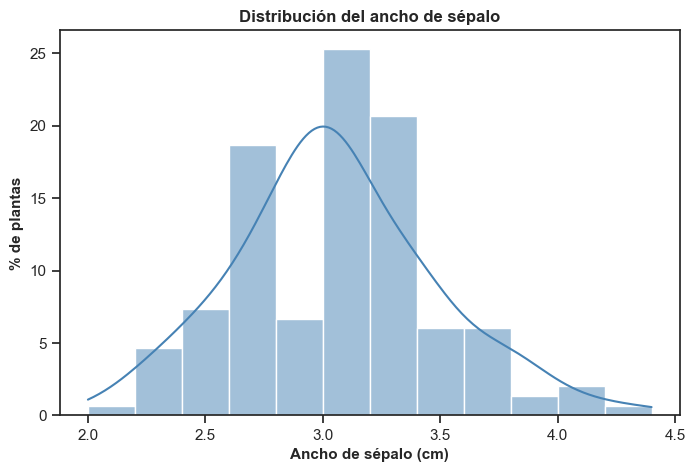

In [2]:
plt.figure(figsize=(8, 5))
sns.histplot(x='sepal_width_cm', data=data_iris, fill=True, color='steelblue',
             edgecolor='white', bins=12, stat='percent', kde=True)
plt.xlabel('Ancho de sépalo (cm)', fontweight='bold', fontsize=11)
plt.ylabel('% de plantas', fontweight='bold', fontsize=11)
plt.title('Distribución del ancho de sépalo', fontweight='bold')
plt.show()

**Observación sobre simetría:** La distribución del ancho de sépalo es aproximadamente simétrica y unimodal, con la mayoría de los valores concentrados entre 2.5 y 3.5 cm. La curva KDE refuerza esta observación al tener forma cercana a una campana.

## Ítem 2 — Distribución del largo del pétalo por especie

C:\Users\PC\AppData\Local\Temp\ipykernel_6936\2921453801.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='petal_length_cm', data=data_iris, palette='Set2')


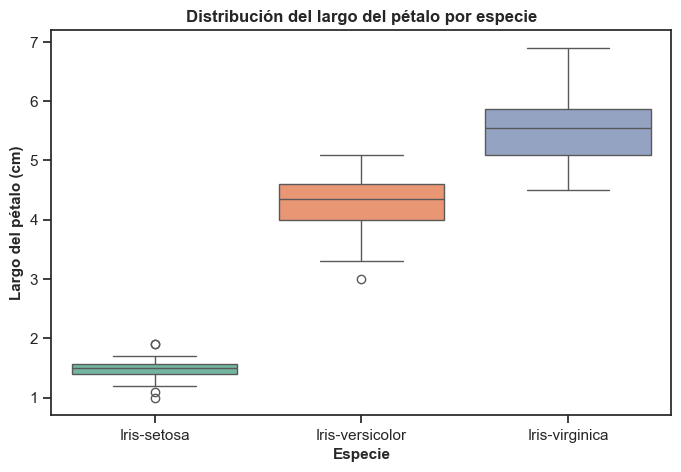

In [3]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='species', y='petal_length_cm', data=data_iris, palette='Set2')
plt.xlabel('Especie', fontweight='bold', fontsize=11)
plt.ylabel('Largo del pétalo (cm)', fontweight='bold', fontsize=11)
plt.title('Distribución del largo del pétalo por especie', fontweight='bold')
plt.show()

**Observación:** Las tres especies presentan distribuciones claramente diferenciadas. *Setosa* tiene pétalos muy cortos (1–1.9 cm) con poca dispersión. *Versicolor* y *virginica* solapan parcialmente, pero *virginica* tiene medianas e IQR más altos. No se observan valores atípicos relevantes en ninguna especie.

## Ítem 3 — Relación entre ancho y largo del pétalo

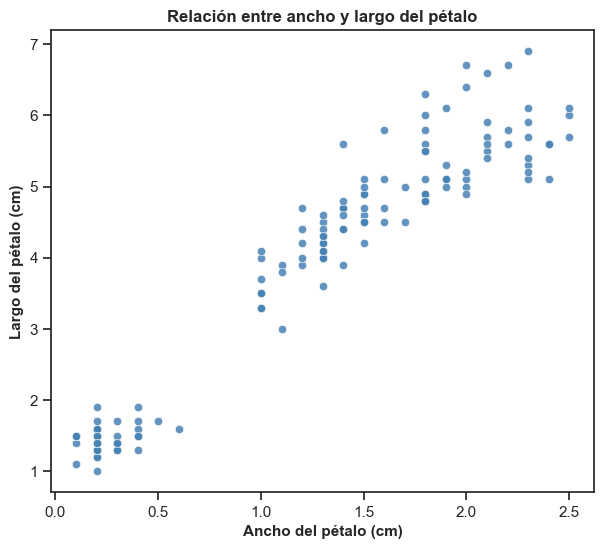

In [4]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x='petal_width_cm', y='petal_length_cm', data=data_iris,
                color='steelblue', edgecolor='white', alpha=0.85)
plt.xlabel('Ancho del pétalo (cm)', fontweight='bold', fontsize=11)
plt.ylabel('Largo del pétalo (cm)', fontweight='bold', fontsize=11)
plt.title('Relación entre ancho y largo del pétalo', fontweight='bold')
plt.show()

**Observación:** Se observa una asociación lineal positiva fuerte entre el ancho y el largo del pétalo. A medida que el ancho aumenta, el largo también lo hace de manera consistente. Se distinguen además dos grupos: uno de valores pequeños (probablemente *setosa*) y otro más disperso con valores mayores.

## Ítem 4 — Scatterplot con diferenciación por especie

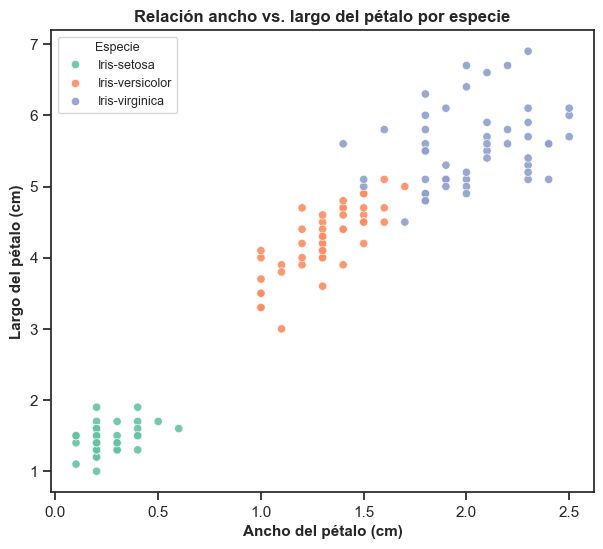

In [5]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x='petal_width_cm', y='petal_length_cm', hue='species',
                data=data_iris, palette='Set2', edgecolor='white', alpha=0.9)
plt.xlabel('Ancho del pétalo (cm)', fontweight='bold', fontsize=11)
plt.ylabel('Largo del pétalo (cm)', fontweight='bold', fontsize=11)
plt.title('Relación ancho vs. largo del pétalo por especie', fontweight='bold')
plt.legend(title='Especie', fontsize=9, title_fontsize=9)
plt.show()

**Observación:** La relación positiva se mantiene dentro de cada especie. *Setosa* ocupa el extremo inferior izquierdo (pétalos pequeños), *versicolor* el sector intermedio y *virginica* el superior derecho. Las tres especies forman grupos separados, lo que confirma que la especie es un factor determinante en el tamaño del pétalo.

## Ítem 5 — Matriz de scatterplots (pairplot)

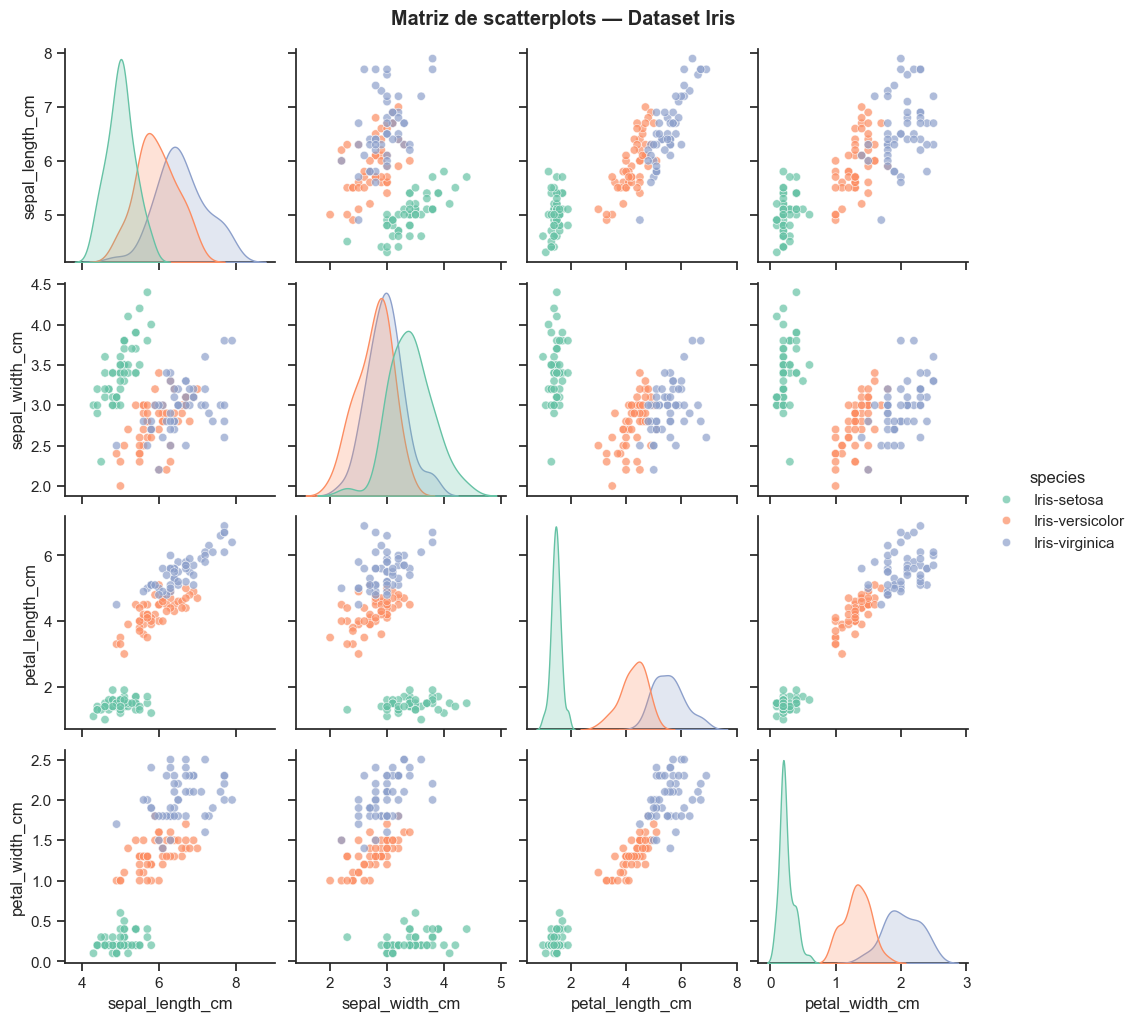

In [6]:
g = sns.pairplot(data_iris[cols_cuant + ['species']], hue='species',
                 diag_kind='kde', palette='Set2', plot_kws={'alpha': 0.7, 'edgecolor': 'white'})
g.figure.suptitle('Matriz de scatterplots — Dataset Iris', y=1.02, fontweight='bold')
plt.show()

## Ítem 6 — Correlograma (correlación lineal de Pearson)

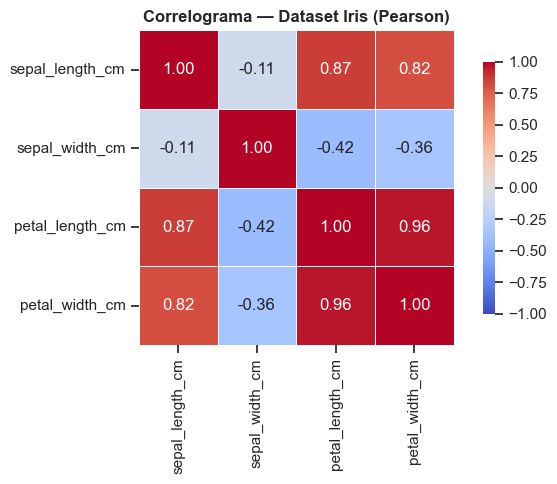

In [7]:
matriz_corr = data_iris[cols_cuant].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlograma — Dataset Iris (Pearson)', fontweight='bold')
plt.tight_layout()
plt.show()

## Ítem 7 — Análisis de la asociación entre pares de variables

A partir del pairplot y el correlograma:

| Par de variables | r (Pearson) | Fuerza | Dirección |
|---|---|---|---|
| largo_pétalo vs. ancho_pétalo | ≈ 0.96 | Muy fuerte | Positiva |
| largo_pétalo vs. largo_sépalo | ≈ 0.87 | Fuerte | Positiva |
| ancho_pétalo vs. largo_sépalo | ≈ 0.82 | Fuerte | Positiva |
| largo_sépalo vs. ancho_sépalo | ≈ −0.11 | Muy débil | Negativa |
| largo_pétalo vs. ancho_sépalo | ≈ −0.42 | Moderada | Negativa |
| ancho_pétalo vs. ancho_sépalo | ≈ −0.37 | Débil-moderada | Negativa |

**Conclusiones:**
- Las variables de **pétalo** (largo y ancho) están fuertemente correlacionadas entre sí y también con el **largo de sépalo**, lo que es visualmente evidente en el pairplot por la disposición lineal de los puntos.
- El **ancho de sépalo** no muestra asociación lineal relevante con las demás variables (correlaciones bajas), coherente con la distribución superpuesta de especies observada en el pairplot.